In [1]:
# %load_ext autoreload
# %autoreload 2

import sys
import string
import scipy as sp
sys.path.insert(0, "../")

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}

import matplotlib.pyplot as plt

import warnings
warnings.simplefilter("ignore")

import numpy as np
import pandas as pd

import seaborn as sns
import scipy.fftpack as fp
from scipy.stats import norm

from sklearn.decomposition import PCA

In [33]:
def readVariableLength(filepath):
    data = pd.read_csv(filepath, sep=" ", header=None)
    return np.array(data.iloc[:, 1:]), np.array(data.iloc[:, 0], dtype=np.int32)


def znorm(data):
    data = (data - np.mean(data, axis=-1, keepdims=True)) / (
            np.std(data, axis=-1, keepdims=True) + 1e-8
    )
    return data


def paa_transform(ts, n_pieces, repeat=True):
    splitted = np.array_split(ts, n_pieces)
    mean = np.asarray(list(map(lambda xs: xs.mean(axis=0), splitted)))

    n = len(ts)
    m = n / n_pieces

    if (repeat):
        means_ext = np.repeat(mean, m, axis=0)
        mean = means_ext

    return np.array(mean)

def _segment_sse(prefix_sum, prefix_sqsum, a, b):
    # SSE for constant fit in [a, b) with mean over that interval
    length = b - a
    if length <= 0: 
        return 0.0
    s = prefix_sum[b] - prefix_sum[a]
    ss = prefix_sqsum[b] - prefix_sqsum[a]
    mean = s / length
    return ss - 2*mean*s + length*(mean**2)

    
def apca_transform(x, k_segments=32, min_len=8):
    n = len(x)
    
    # Start with single segment [0, n)
    segments = [(0, n)]
    
    if k_segments <= 1:
        return ([x.mean()], segments)
        
    # Prefix sums for O(1) SSE
    prefix_sum = np.zeros(n+1)
    prefix_sqsum = np.zeros(n+1)
    prefix_sum[1:] = np.cumsum(x)
    prefix_sqsum[1:] = np.cumsum(x**2)

    
    # While fewer than k segments, split the segment that gives best SSE reduction
    while len(segments) < k_segments:
        best_gain = 0.0
        best_choice = None
        # Evaluate splitting each segment
        for si, (a, b) in enumerate(segments):
            if b - a >= 2*min_len:
                sse_parent = _segment_sse(prefix_sum, prefix_sqsum, a, b)
                # Search best split
                # (coarse scan step for speed; refine around best if desired)
                step = max((b - a)//64, 1)
                for c in range(a + min_len, b - min_len + 1, step):
                    sse_left  = _segment_sse(prefix_sum, prefix_sqsum, a, c)
                    sse_right = _segment_sse(prefix_sum, prefix_sqsum, c, b)
                    gain = sse_parent - (sse_left + sse_right)
                    if gain > best_gain:
                        best_gain = gain
                        best_choice = (si, c)
        if best_choice is None:
            break
        si, c = best_choice
        a, b = segments[si]
        segments[si:si+1] = [(a, c), (c, b)]

    x_hat = np.zeros(k_segments)
    for i, (a, b) in enumerate(segments):
        x_hat[i] = x[a:b].mean()
        
    return x_hat, segments

def asax_transform(apca_ts, segments, alphabet):
    alphabet_sz = len(alphabet)
    breakpoints = norm.ppf(np.linspace(1. / alphabet_sz, 1 - 1. / alphabet_sz, alphabet_sz - 1))

    def translate(ts_values):
        return np.asarray([(alphabet[0] if ts_value < breakpoints[0] else (alphabet[-1] if ts_value > breakpoints[-1] else alphabet[np.where(breakpoints <= ts_value)[0][-1] + 1])) for ts_value in ts_values])

    sax_ts = np.apply_along_axis(translate, 0, apca_ts)
    return sax_ts, np.repeat(apca_ts, [b-a for a,b in segments]), breakpoints
    

def sax_transform(ts, n_pieces, alphabet):
    alphabet_sz = len(alphabet)
    breakpoints = norm.ppf(
        np.linspace(1. / alphabet_sz, 1 - 1. / alphabet_sz, alphabet_sz - 1))

    def translate(ts_values):
        return np.asarray([(alphabet[0] if ts_value < breakpoints[0]
                            else (alphabet[-1] if ts_value > breakpoints[-1]
                                  else alphabet[
            np.where(breakpoints <= ts_value)[0][-1] + 1]))
                           for ts_value in ts_values])

    paa_ts = paa_transform(ts, n_pieces, False)
    sax_ts = np.apply_along_axis(translate, 0, paa_ts), breakpoints
    return sax_ts, paa_ts, breakpoints


def translate(ts_value, alphabet, breakpoints):
    if ts_value < breakpoints[0]:
        return 0
    elif ts_value > breakpoints[-1]:
        return len(alphabet) - 1
    else:
        return np.where(breakpoints <= ts_value)[0][-1] + 1


def dft(ts, segments, variance=True):
    dft = fp.rfft(ts)

    if variance:
        # determine variance
        dft_variance = np.var(dft, axis=0)
    
        # select word-length-many indices with the largest variance
        support = np.argsort(-dft_variance)[: segments + 1]
    
        # sort remaining indices
        support = np.sort(support)
    else: 
        support = np.arange(segments+1)
        
    return dft[:, support], support



def idft(ts, originalSize):
    return fp.irfft(ts, originalSize)


def calcInverseSFA(BINs, SFA_SAMPLE, window, support):
    # print(support)

    U_SFA_SAMPLE = SFA_SAMPLE
    U_SFA_SAMPLE[SFA_SAMPLE == len(BINs[0])] = len(BINs[0]) - 1

    upperBounds = np.array(
        [BINs[j][np.array(U_SFA_SAMPLE[j])] for j in range(len(SFA_SAMPLE))])
    lowerBounds = np.array(
        [BINs[j][np.array(SFA_SAMPLE[j] - 1)] for j in range(len(SFA_SAMPLE))])

    # print(upperBounds.shape)

    u_full = np.zeros((window))
    l_full = np.zeros((window))
    u_full[support] = upperBounds
    l_full[support] = lowerBounds

    upperBounds = fp.irfft(u_full)
    lowerBounds = fp.irfft(l_full)

    return (upperBounds, lowerBounds)

def mcb_bins(X, symbols):
    quantiles = np.linspace(0.0, 1.0, symbols + 1)
    bins = np.array([
        np.quantile(X[:, j], quantiles)
        for j in range(X.shape[1])
    ])
    return bins


def mcb_transform(coeffs, bins):
    symbols = bins.shape[1] - 1

    word = np.empty(len(coeffs), dtype=np.int32)

    for j, value in enumerate(coeffs):
        word[j] = np.searchsorted(
            bins[j, 1:-1],
            value,
            side="right"
        )

        word[j] = np.clip(
            word[j],
            0,
            symbols - 1
        )

    return word


def spartan_transform(train, n_components, symbols):
    """
    Simplified SPARTAN:
        PCA -> MCB

    train: normalized training data, shape (n_samples, ts_length)
    """
    pca = PCA(n_components=n_components)
    coeffs = pca.fit_transform(train)
    bins = mcb_bins(coeffs, symbols)

    return coeffs, bins, pca


def calcInverseSPARTAN(bins, word, pca):
    """
    Compute a time-domain envelope corresponding to the PCA coefficient
    intervals represented by a SPARTAN word.

    Importantly, simply inverse_transform(lower) and inverse_transform(upper)
    is NOT correct because PCA loadings may be negative.

    For each time position we therefore compute the exact min/max of the
    PCA hyperrectangle.
    """
    n_components = len(word)

    lower_coeffs = np.empty(n_components)
    upper_coeffs = np.empty(n_components)

    for j, symbol in enumerate(word):
        lower_coeffs[j] = bins[j, symbol]
        upper_coeffs[j] = bins[j, symbol + 1]
        
    components = pca.components_[:n_components]

    lower_time = pca.mean_.copy()
    upper_time = pca.mean_.copy()

    for j in range(n_components):
        w = components[j]

        contribution_a = lower_coeffs[j] * w
        contribution_b = upper_coeffs[j] * w

        lower_time += np.minimum(contribution_a, contribution_b)
        upper_time += np.maximum(contribution_a, contribution_b)

    return upper_time, lower_time
    
def plot_sax_vs_sfa(train, all_features=[4, 8, 12], ts_pos=5, alpha=256):
    alphabet = np.arange(alpha)
    # list(string.ascii_lowercase) #['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
    colors = sns.color_palette("tab10")

    # print("Norming")
    train = znorm(train)
    ts1 = train[ts_pos]

    # print("Done Norming")

    n = len(ts1)
    symbols = len(alphabet)

    fs_title = 32
    fs_labels = 22

    fig, axes = plt.subplots(
        5, len(all_features) + 1, figsize=(5 + len(all_features) * 6, 10), 
        facecolor='white',
        sharex=True, sharey=True)

    ax = axes[0, 0]
    ax.set_title("Raw Data Series", fontsize=fs_title)
    ax.plot(ts1, lw=2, c=colors[0])

    for aa, features in enumerate(all_features):
        ##### PAA        
        paa_ts = paa_transform(ts1, features, True)
        sax_ts, _, sax_breakpoints = sax_transform(ts1, features, alphabet)

        # append min and max value to the breakpoints
        breakpoints_new = [np.min(ts1)]
        breakpoints_new.extend(sax_breakpoints)
        breakpoints_new.append(np.max(ts1))
        breakpoints_new = np.array(breakpoints_new)

        ax = axes[0, aa+1]
        ax.set_title("SAX, D=" + str(features), fontsize=fs_title)
        ax.plot(ts1, lw=2, c=colors[0])

        for c, paa in enumerate(paa_ts):
            ts_value = translate(paa, alphabet, sax_breakpoints)
            maxValue = breakpoints_new[ts_value + 1]
            minValue = breakpoints_new[ts_value]
            rect = plt.Rectangle(
                (c, minValue), width=1,
                height=abs(maxValue - minValue), color=colors[1])
            ax.add_patch(rect)

        ax.plot(paa_ts, lw=2, c=colors[1], label='PAA')

        ##### SFA
        ax = axes[2, aa+1]
        ax.set_title("SFA, D=" + str(features), fontsize=fs_title)
        ax.plot(ts1, lw=2, c=colors[0], label='SFA')
        
        DFTs, support = dft(train, features, variance=False)
        BINs = mcb_bins(DFTs, symbols)    
        SFA_SAMPLE = mcb_transform(DFTs[ts_pos], BINs)
        upperBounds, lowerBounds = calcInverseSFA(BINs, SFA_SAMPLE, len(ts1), support)
        
        xx = np.arange(0, len(ts1))
        ax.plot(xx, upperBounds, lw=2, c=colors[1])
        ax.plot(xx, lowerBounds, lw=2, c=colors[1])
        ax.fill_between(xx, lowerBounds, upperBounds, edgecolor=colors[1], facecolor=colors[1])

        ##### SOFA
        ax = axes[3, aa+1]
        ax.set_title("SOFA, D=" + str(features), fontsize=fs_title)
        ax.plot(ts1, lw=2, c=colors[0], label='SOFA')

        DFTs, support = dft(train, features, variance=True)
        BINs = mcb_bins(DFTs, symbols)    
        SFA_SAMPLE = mcb_transform(DFTs[ts_pos], BINs)
        upperBounds, lowerBounds = calcInverseSFA(BINs, SFA_SAMPLE, len(ts1), support)
        
        ax.plot(xx, upperBounds, lw=2, c=colors[1])
        ax.plot(xx, lowerBounds, lw=2, c=colors[1])
        ax.fill_between(xx, lowerBounds, upperBounds, edgecolor=colors[1], facecolor=colors[1])
        
        ##### SPARTAN
        ax = axes[4, aa + 1]
        ax.set_title("SPARTAN, D=" + str(features), fontsize=fs_title)
        ax.plot(ts1, lw=2, c=colors[0], label='SPARTAN')
        PCA_coeffs, PCA_BINs, pca = spartan_transform(train, n_components=features, symbols=symbols)

        SPARTAN_SAMPLE = mcb_transform(PCA_coeffs[ts_pos], PCA_BINs)
        upperBounds, lowerBounds = calcInverseSPARTAN(PCA_BINs, SPARTAN_SAMPLE, pca)
        ax.plot(xx, upperBounds, lw=2, c=colors[1])
        ax.plot(xx, lowerBounds, lw=2, c=colors[1])
        ax.fill_between(xx, lowerBounds, upperBounds, edgecolor=colors[1], facecolor=colors[1])

        sns.despine()
        
        #### ASAX
        ax = axes[1, aa + 1]
        ax.set_title("ASAX, D=" + str(features), fontsize=fs_title)
        ax.plot(ts1, lw=2, c=colors[0], label='ASAX')
        apca_ts, segments = apca_transform(ts1, k_segments=features, min_len=4)
        asax_ts, apca_full, sax_breakpoints = asax_transform(apca_ts, segments, alphabet)
        
        breakpoints_new = np.r_[np.min(ts1), sax_breakpoints, np.max(ts1)]
        
        for paa, (a, b) in zip(apca_ts, segments):
            s = translate(paa, alphabet, sax_breakpoints)
            ax.add_patch(plt.Rectangle((a, breakpoints_new[s]), b-a, breakpoints_new[s+1]-breakpoints_new[s], color=colors[1]))
        
        ax.plot(apca_full, lw=2, c=colors[1], label='ASAX')
        
        sns.despine()

    for ax in fig.axes:
        ax.axis('tight')
        for t in ax.get_xticklabels():
            t.set_rotation(-45); t.set_fontsize(fs_labels)
        ax.set_xlabel('Time', fontsize=fs_labels)
        ax.set_ylabel('Value', fontsize=fs_labels)        
        

    # remove empty subplots
    fig.delaxes(axes[1, 0])
    fig.delaxes(axes[2, 0])
    fig.delaxes(axes[3, 0])    
    fig.delaxes(axes[4, 0])    
    
    plt.tight_layout()
    
    return fig

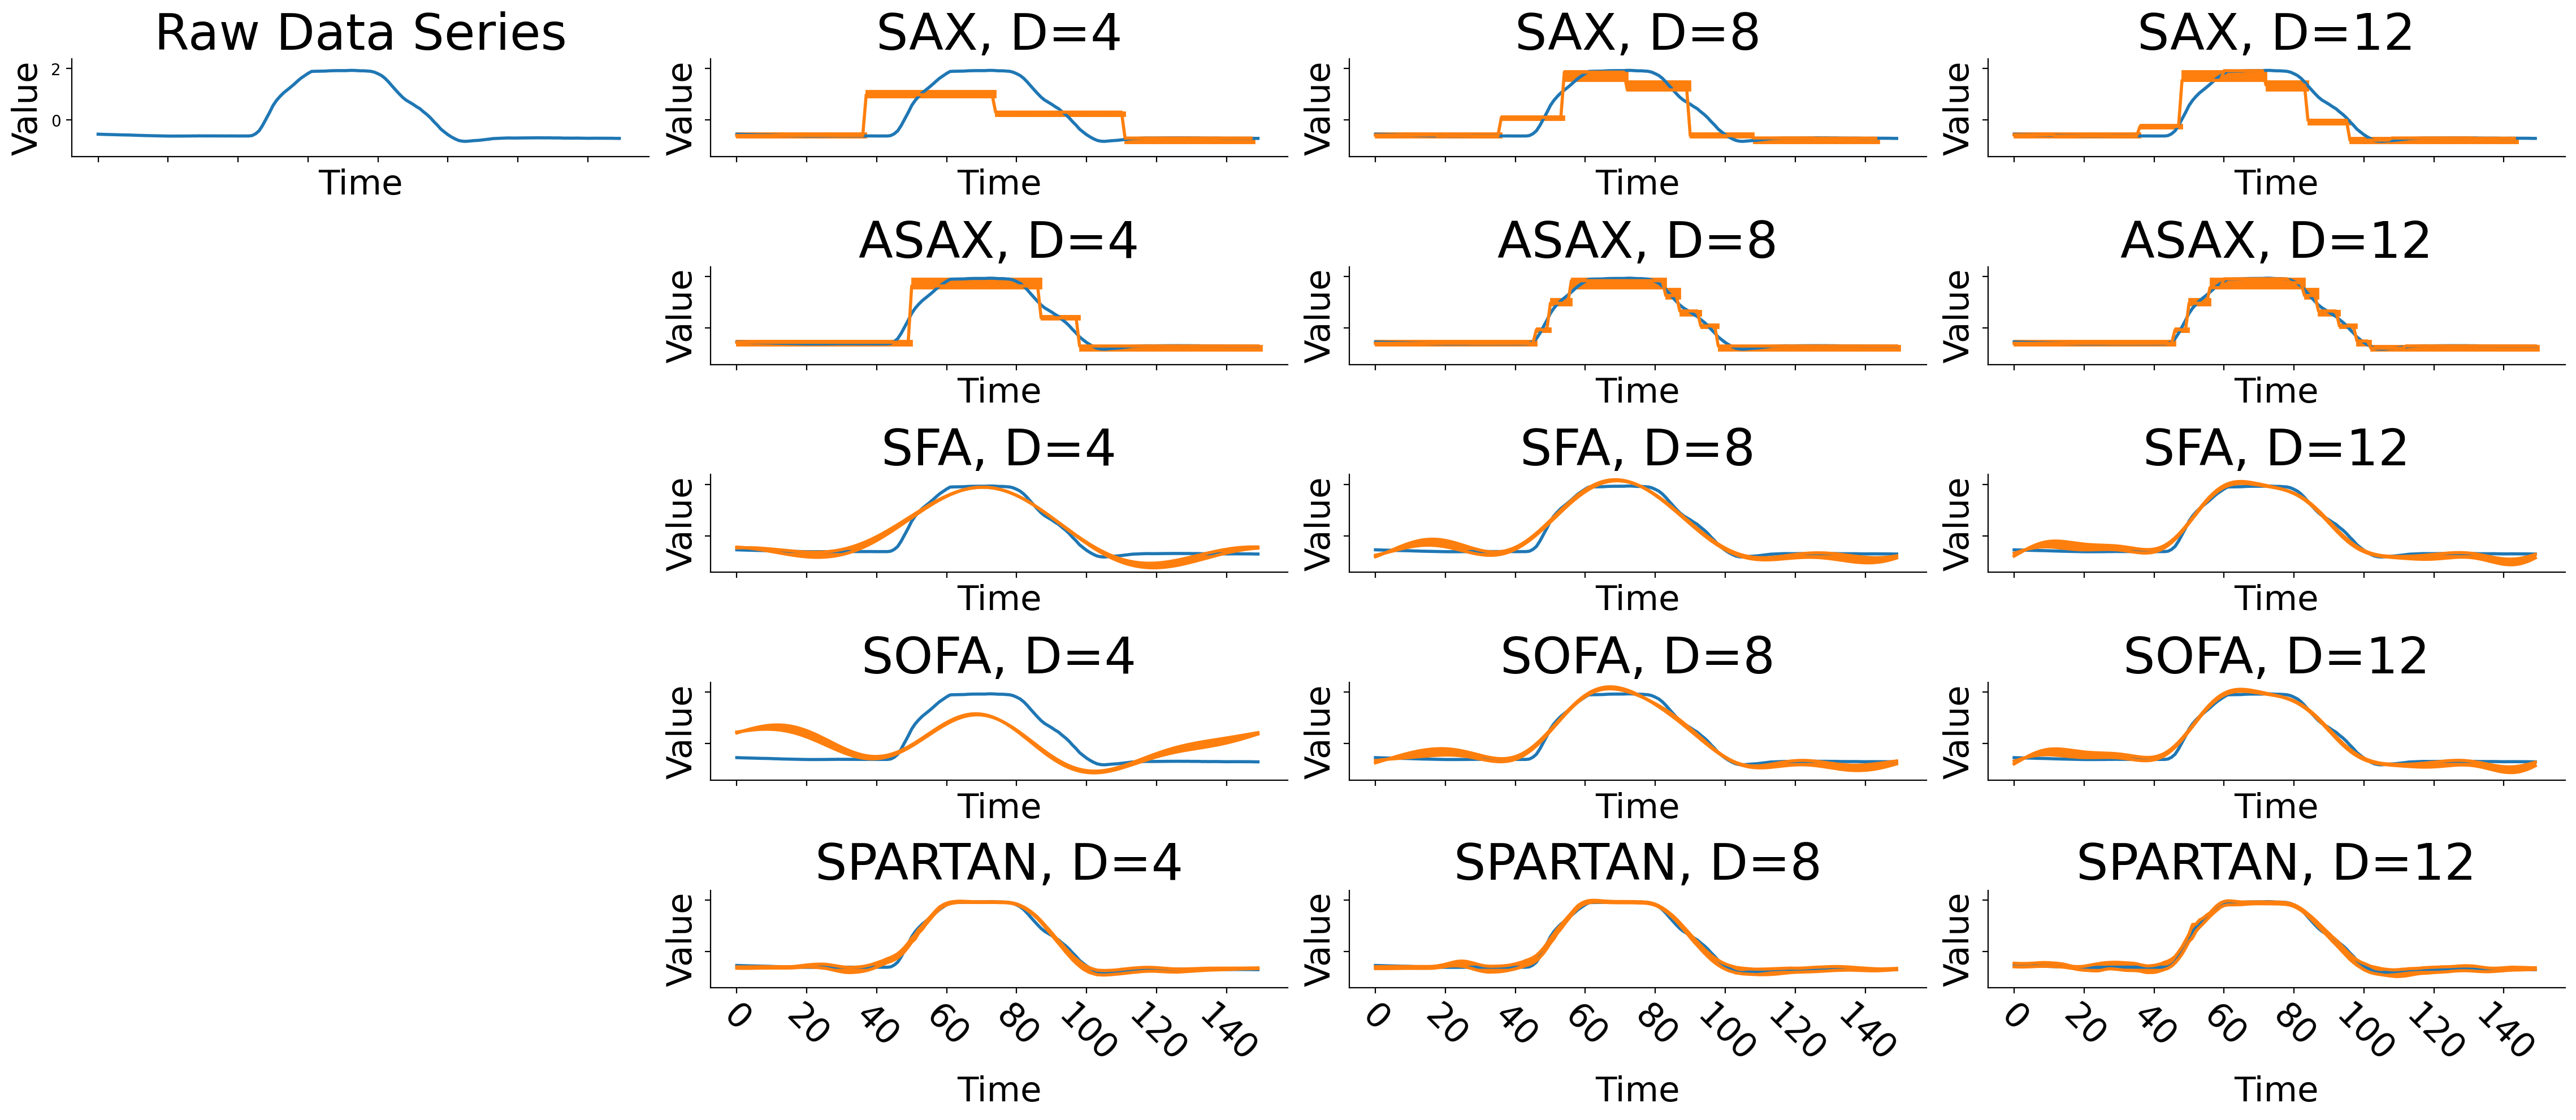

In [34]:
train, labels = readVariableLength('Gun_Point/Gun_Point_TRAIN')
train.shape

fig = plot_sax_vs_sfa(train, alpha=16)
#plt.savefig('images/sax_vs_sfa_Gun_point.pdf', format='pdf',
#                facecolor=fig.get_facecolor(), edgecolor='none')
plt.show()

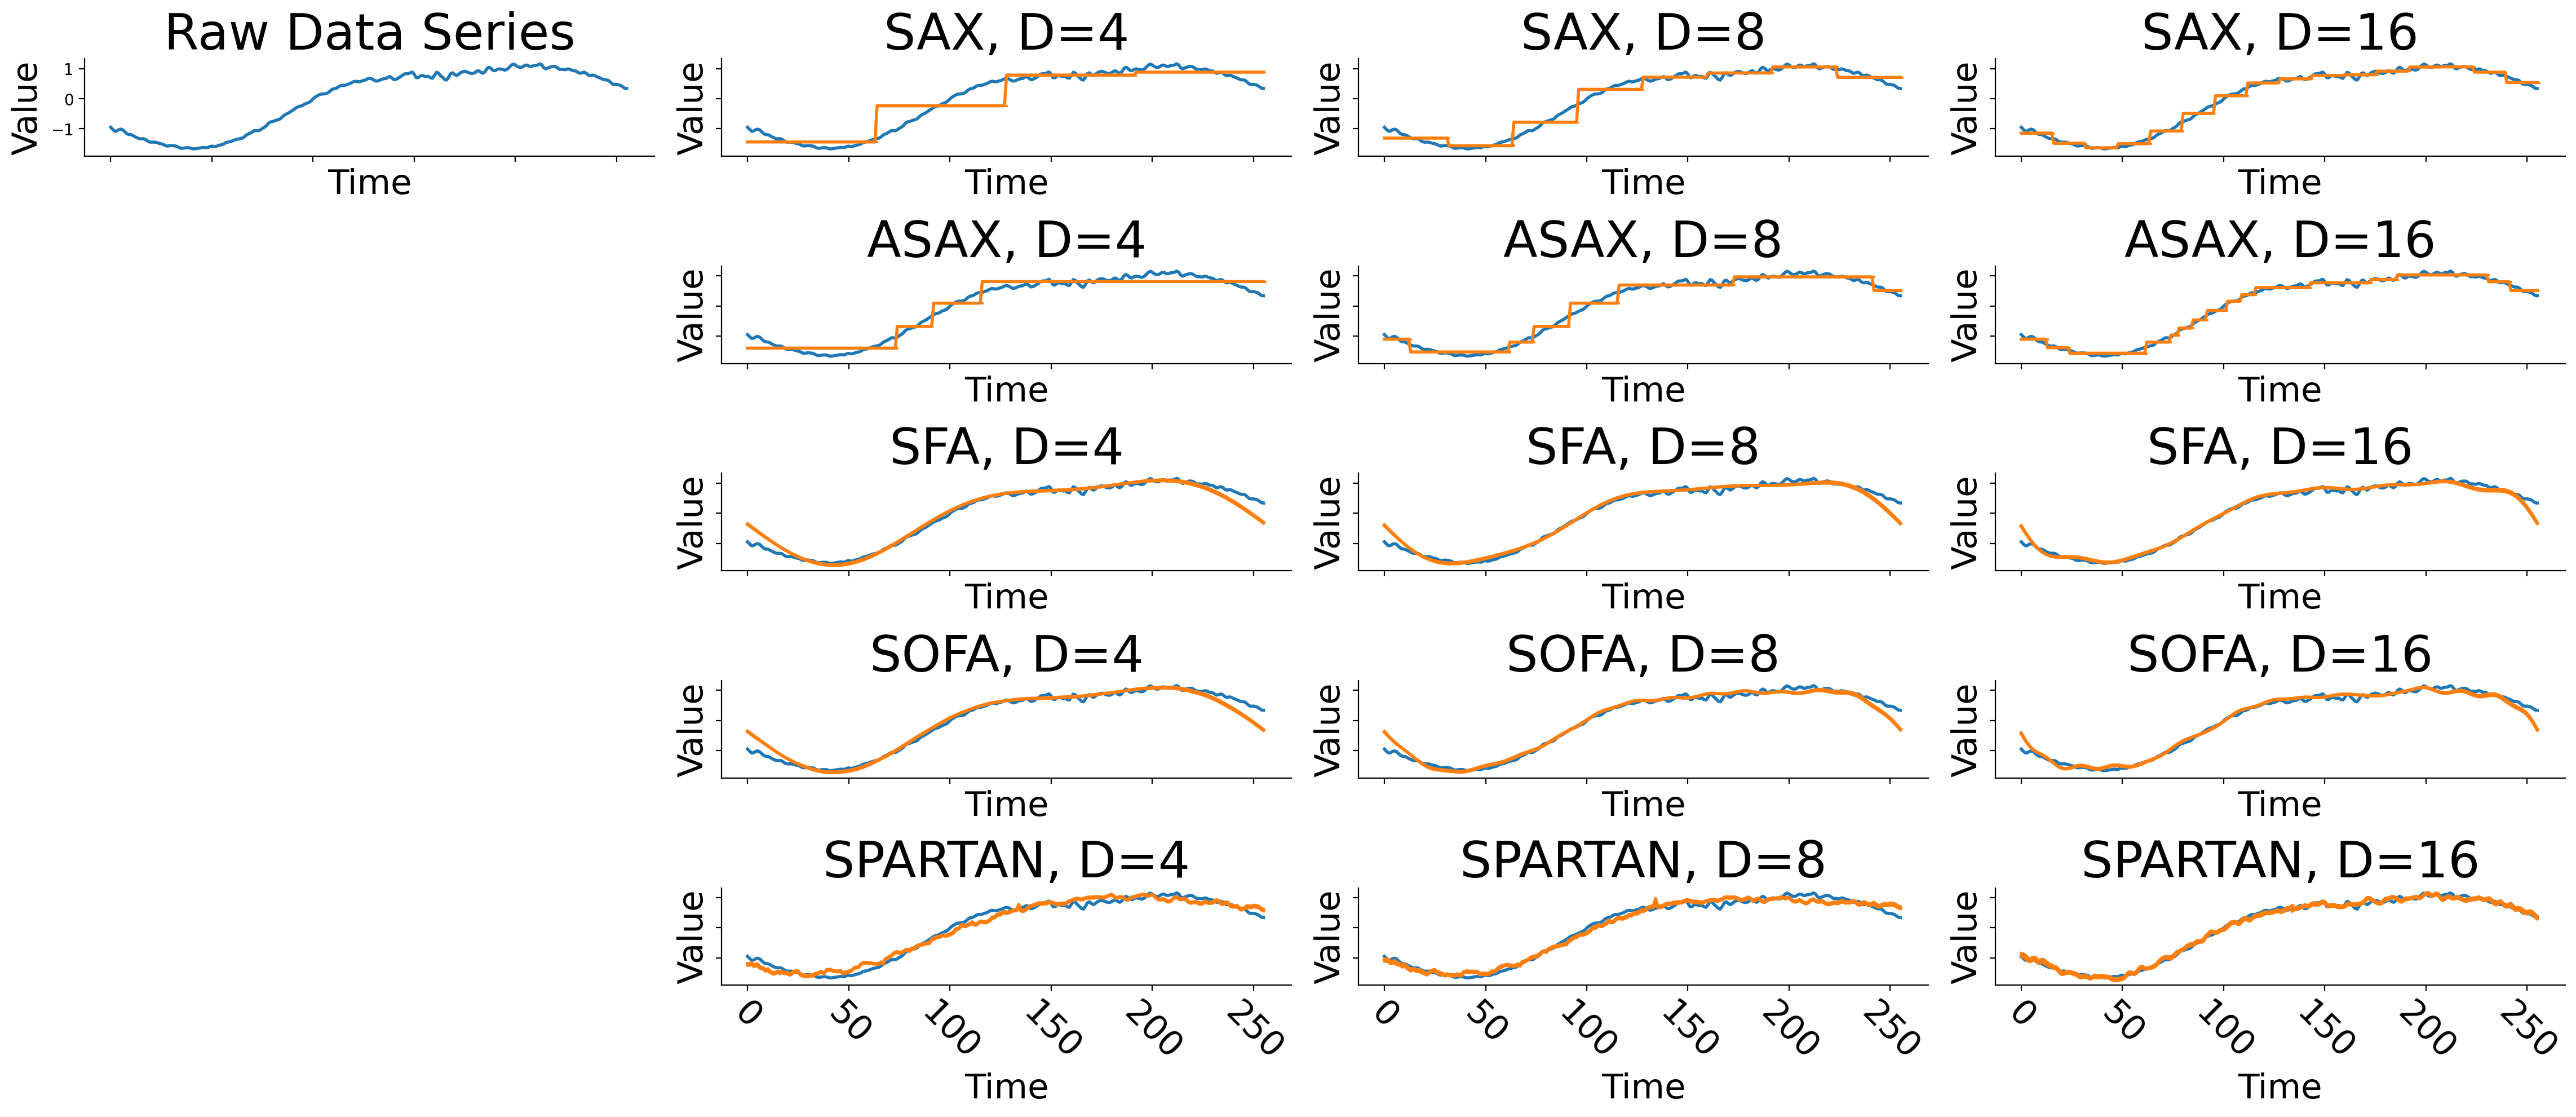

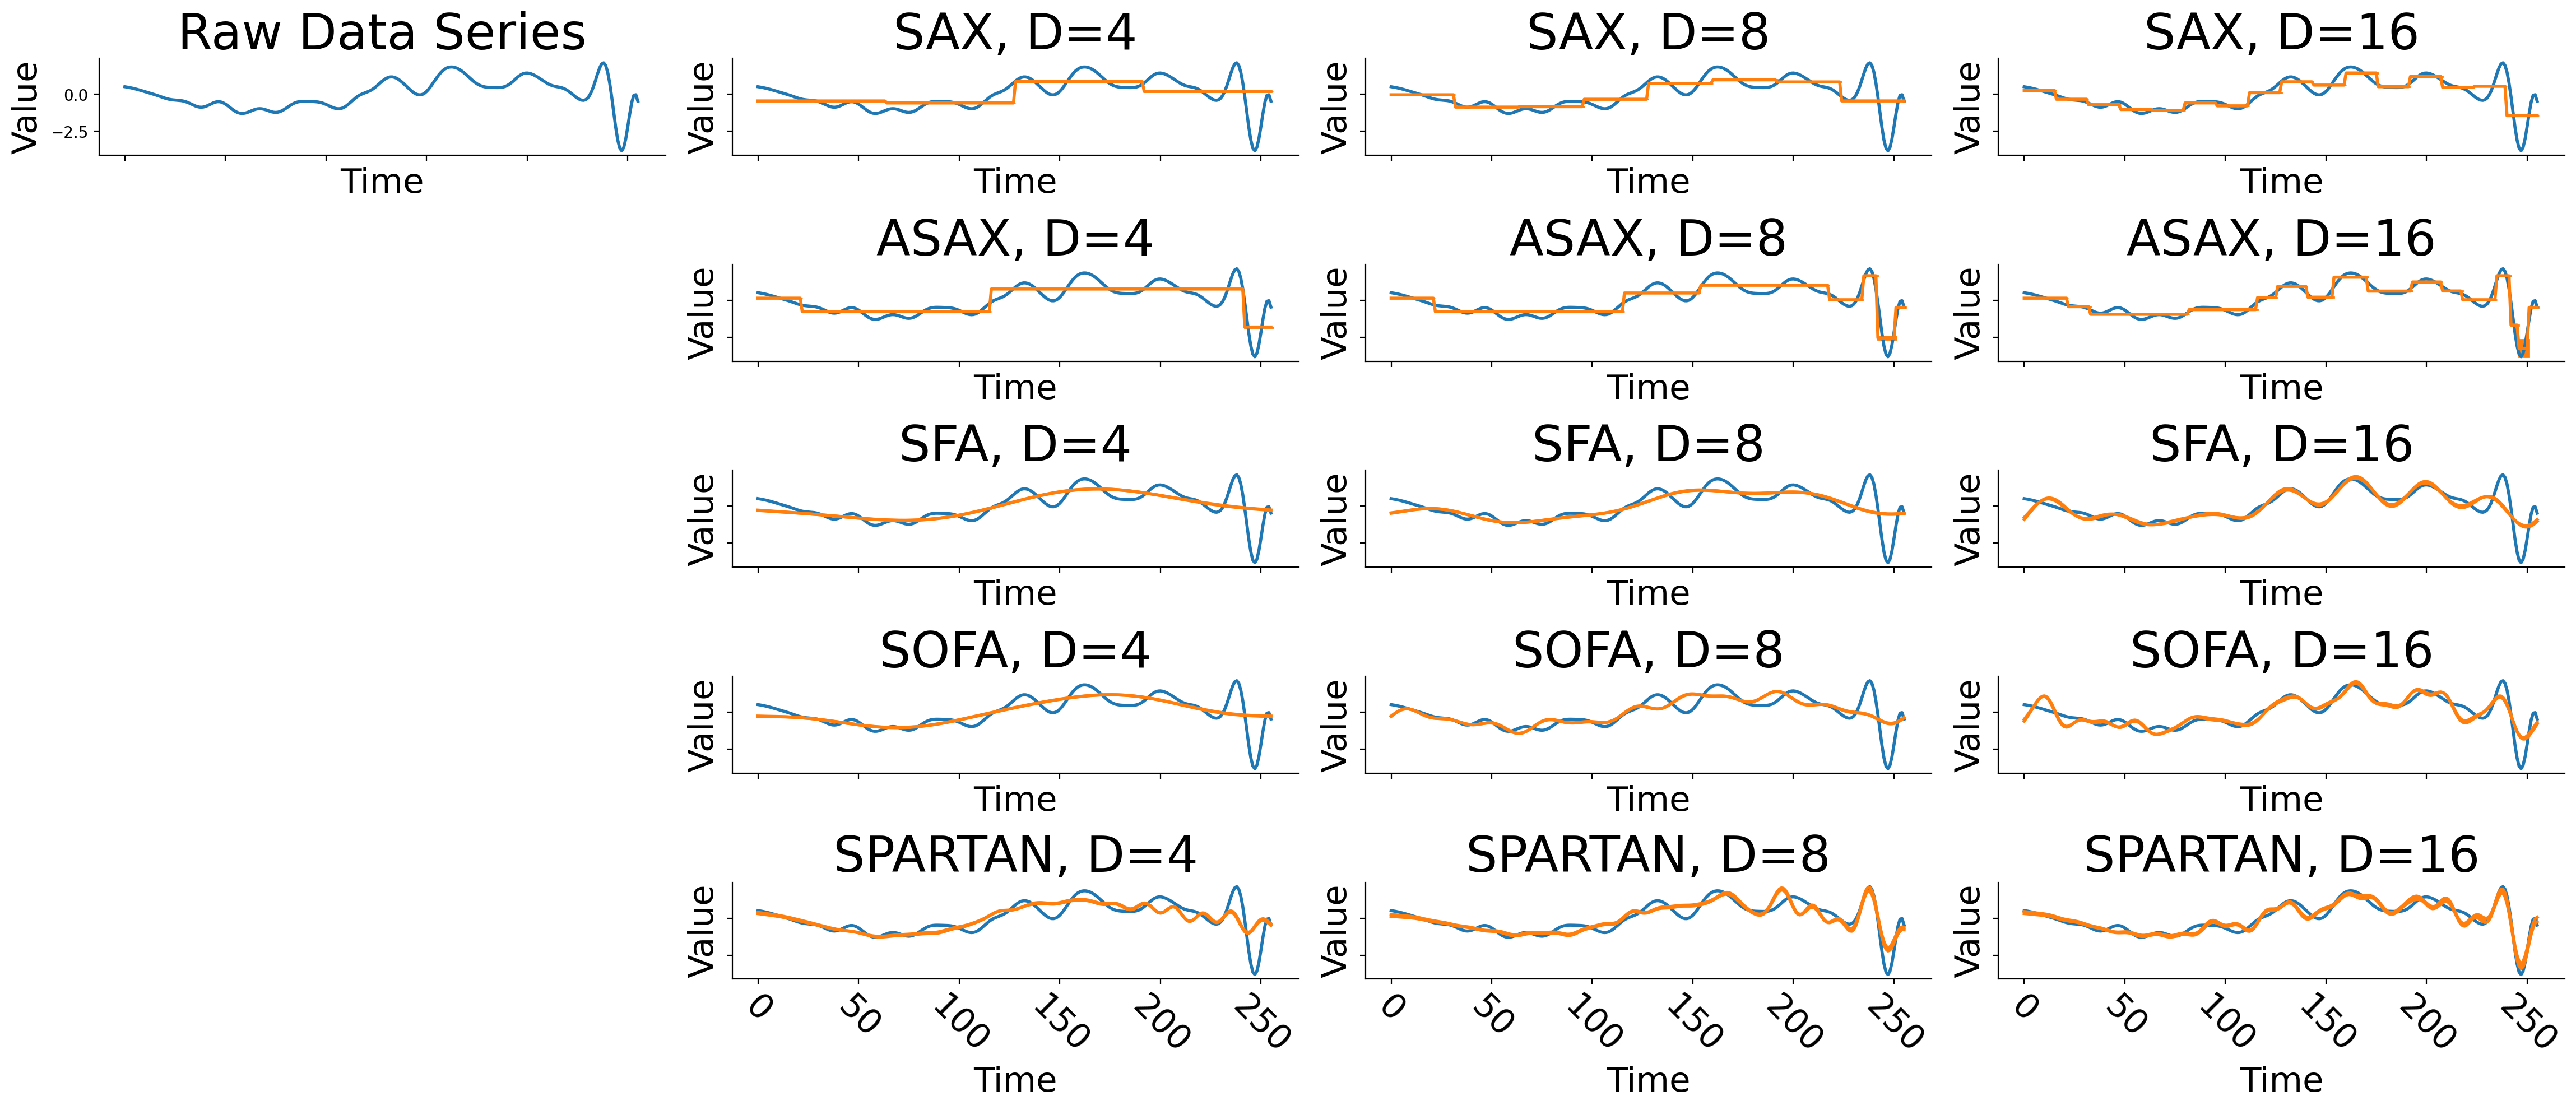

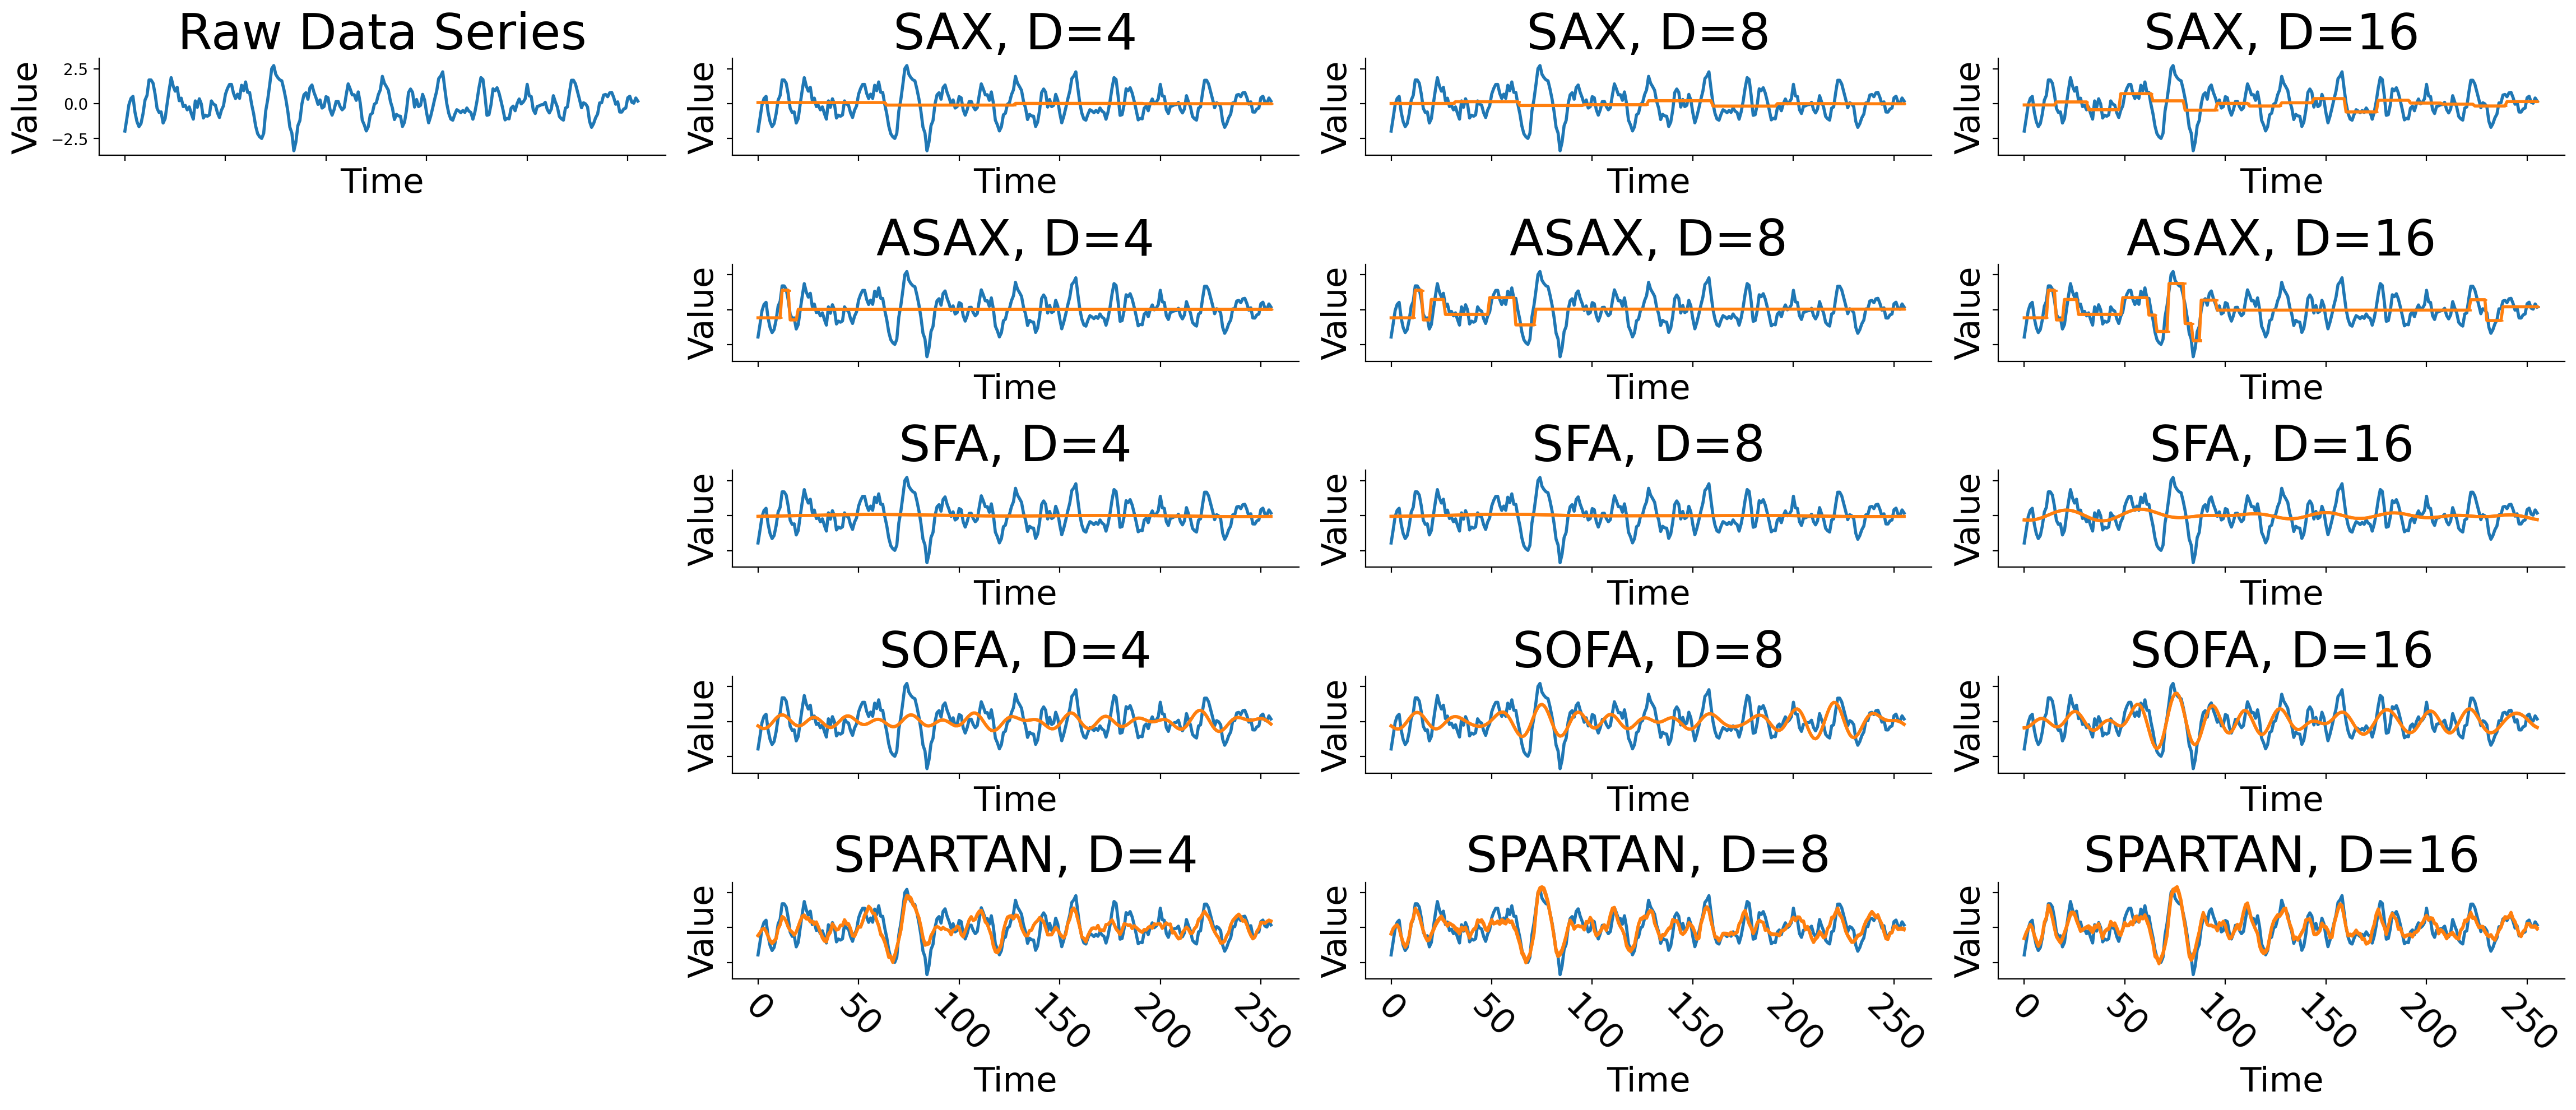

In [35]:
for ds in ["OBS", "LenDB", "SCEDC"]:
    file = f'queries/{ds}_queries.bin'
    length = 256
    data_type=np.float32    
    data = np.fromfile(file, dtype=data_type)
    
    train = (data[:len(data)-len(data)%length].reshape(-1, length))
    # train = sp.stats.zscore(train, axis = 1)
    
    fig = plot_sax_vs_sfa(train, all_features=[4, 8, 16], ts_pos = 20, alpha=256)
    plt.savefig(
        f'images/sax_vs_sfa_vs_spartan_{ds}.pdf', format='pdf',
        facecolor=fig.get_facecolor(), edgecolor='none'
    )
    plt.show()

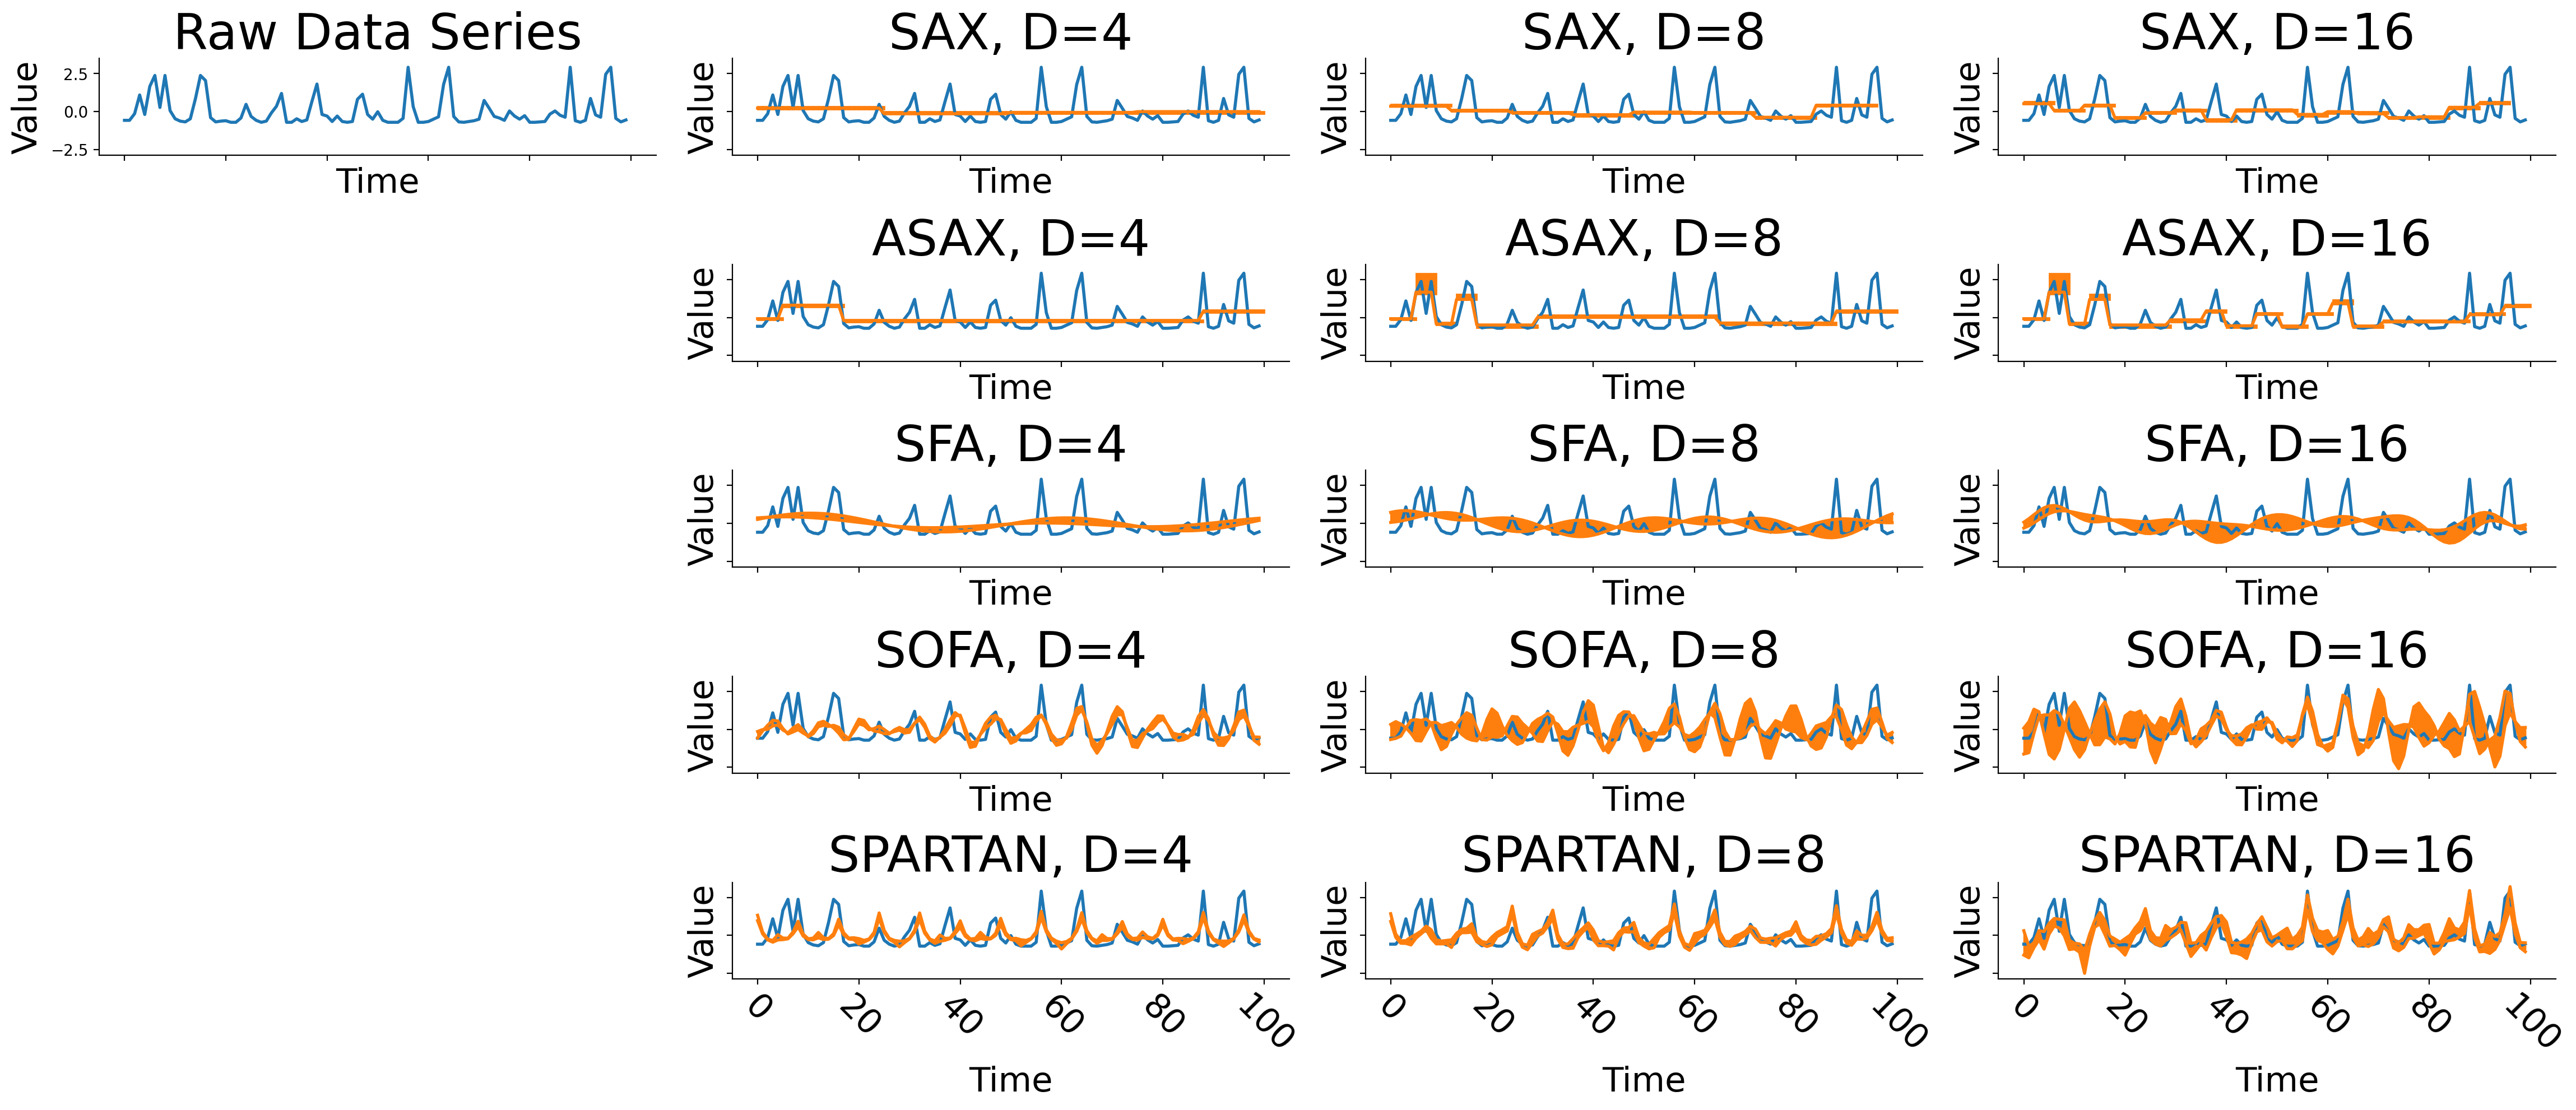

In [36]:
file = 'queries/bigANN_queries.bin'
length = 100
data_type=np.uint8
data = np.fromfile(file, dtype=data_type)

train = (data[:len(data)-len(data)%length].reshape(-1, length))
train = sp.stats.zscore(train, axis = 1)

fig = plot_sax_vs_sfa(train, all_features=[4, 8, 16], ts_pos = 2, alpha=16)
plt.savefig('images/sax_vs_sfa_vs_spartan_bigANN.pdf', format='pdf',
                facecolor=fig.get_facecolor(), edgecolor='none')
plt.show()